In [1]:

from cipo import user

In [2]:
code_obs = 'Y28'          # código do observatório (ex: OASI)
type_object = 'NEOCP'       # ou 'PCCP'
altitude_min = 20          # graus
time_min = 45

In [3]:
df_complete = user.mpc_objects(type_object)

Download error
No data obtained.


In [4]:
df_complete

,Temp Desig,Score,Discovery,R.A.,Decl.,V,Updated,Note,NObs,Arc,H,Not_Seen_dys
0,oDK0085,79.0,2026 02 21.7,10 08.7,+06 50,23.2,Added Feb. 26.56 UT,NaN,50.0,0.03,26.5,4.818
1,P12mbhW,98.0,2026 02 26.5,11 43.2,-20 30,19.9,Added Feb. 26.55 UT,NaN,3.0,0.03,27.4,0.050
2,C1CP2K5,98.0,2026 02 26.5,12 18.7,+29 40,22.6,Added Feb. 26.55 UT,NaN,4.0,0.02,24.4,0.085
3,C1CP3M5,100.0,2026 02 26.5,12 40.8,+33 55,21.3,Updated Feb. 26.55 UT,NaN,8.0,0.04,25.8,0.028
4,C1CP325,99.0,2026 02 26.5,12 48.6,+31 48,22.1,Added Feb. 26.53 UT,NaN,4.0,0.02,24.7,0.055
5,CE99GJ2,100.0,2026 02 26.5,17 03.3,+47 52,20.8,Updated Feb. 26.54 UT,NaN,8.0,0.03,22.2,0.038
6,C1CP135,100.0,2026 02 26.5,12 13.9,+27 51,21.5,Updated Feb. 26.54 UT,NaN,8.0,0.05,25.0,0.045
7,C1CNZ55,98.0,2026 02 26.4,11 34.0,+24 41,22.4,Updated Feb. 26.53 UT,NaN,7.0,0.09,27.8,0.045
8,C1CNZ15,98.0,2026 02 26.4,11 39.0,+23 25,21.0,Updated Feb. 26.53 UT,NaN,8.0,0.09,29.0,0.048
9,C1CNVD5,100.0,2026 02 26.4,11 36.0,+22 43,22.7,Added Feb. 26.47 UT,NaN,4.0,0.02,24.1,0.122


In [5]:
local = user.get_observatory_location(code_obs)
if local is None:
    raise ValueError("Observatório não encontrado")

In [6]:
altitude_min = 20          # graus
time_min = 45             # minutos

df_filtared = user.filter_visible_objects(df_complete, local,
                                          altitude_min=altitude_min,
                                          time_min_minutes=time_min)

if df_filtared.empty:
    print("None.")
else:
    df_filtared
    cols_show = ['Temp Desig', 'R.A.', 'Decl.', 'V', 'Visible_Minutes', 'Max_Alt']
    display(df_filtared[cols_show])

,Temp Desig,R.A.,Decl.,V,Visible_Minutes,Max_Alt
0,oDK0085,10 08.7,+06 50,23.2,540,74.5
1,P12mbhW,11 43.2,-20 30,19.9,570,78.0
2,C1CP2K5,12 18.7,+29 40,22.6,495,51.8
3,C1CP3M5,12 40.8,+33 55,21.3,480,47.5
4,C1CP325,12 48.6,+31 48,22.1,480,49.6
5,CE99GJ2,17 03.3,+47 52,20.8,375,33.4
6,C1CP135,12 13.9,+27 51,21.5,495,53.5
7,C1CNZ55,11 34.0,+24 41,22.4,495,56.7
8,C1CNZ15,11 39.0,+23 25,21.0,510,58.0
9,C1CNVD5,11 36.0,+22 43,22.7,510,58.7


In [7]:
object_selected = df_filtared.iloc[78]['Temp Desig']

page_ephemeris = user.fetch_mpc_data(type_object, code_obs)

if page_ephemeris is None:
    print("Failed to fetch MPC data. Please check the observatory code or object type.")
else:
    dict_ephemeris = user.parse_mpc_data(page_ephemeris)
    if object_selected in dict_ephemeris:
        df_ephemeris = dict_ephemeris[object_selected]
        #print(f"\nEfemérides de {object_selected}:")
        display(df_ephemeris)
    else:
        print(f"No ephemeris data found for {object_selected}.")
        

Iniciando coleta de efemérides via Selenium para NEOCP (Obs: Y28)...


,Date,UT,R.A. (J2000),Decl,Elong,V,Motion min,Motion PA
0,2026 02 26,14,02 11 39.4,-03 52 18,53.5,21.4,2.97,084.4
1,2026 02 26,15,02 11 51.3,-03 52 00,53.5,21.4,2.97,084.3
2,2026 02 26,16,02 12 03.1,-03 51 43,53.5,21.4,2.96,084.3
3,2026 02 26,17,02 12 14.9,-03 51 25,53.5,21.4,2.96,084.3
4,2026 02 26,18,02 12 26.7,-03 51 07,53.5,21.4,2.95,084.3
5,2026 02 26,19,02 12 38.4,-03 50 50,53.5,21.4,2.95,084.3
6,2026 02 26,20,02 12 50.2,-03 50 32,53.5,21.4,2.95,084.3
7,2026 02 26,21,02 13 02.0,-03 50 14,53.5,21.4,2.96,084.3
8,2026 02 26,22,02 13 13.8,-03 49 56,53.5,21.4,2.96,084.3
9,2026 02 26,23,02 13 25.6,-03 49 39,53.6,21.4,2.97,084.3


In [7]:
df_visible = user.process_mpc_data(code_obs, type_object, interactive_mode=True)

Temp Desig    R.A.  Decl.    V  Visible_Minutes  Max_Alt
   P22m9sS 13 03.2 -08 38 21.1              660     89.4
   P12m9wo 12 16.4 -09 39 21.4              660     88.9
   P12m2Rl 14 06.5 -08 31 20.8              660     88.6
   P12lDlO 08 58.5 -07 05 22.1              660     88.4
   A11yCiF 21 14.2 -06 44 32.8              645     87.8
   P22m9tq 09 58.7 -10 53 21.3              675     87.7
   CE8K6Y2 12 57.3 -10 49 20.0              675     87.6
   ST26B48 09 14.6 -11 00 20.5              660     87.6
   P12ly16 11 04.3 -05 44 20.9              660     87.0
    X89330 12 35.0 -05 16 18.4              660     86.5
   C1CATD5 09 15.8 -04 40 21.8              660     86.0
   v23feb6 02 09.1 -03 56 21.4              630     84.8
   CE8TQD2 11 00.2 -03 04 20.7              660     84.5
   orA2414 09 49.9 -02 51 21.6              660     84.1
   P12m83M 12 17.8 -14 34 20.0              660     84.0
   ZTF10Bn 10 33.9 -02 37 20.0              660     84.0
   C1CC4M5 09 56.6 -02 31 23.0 

Iniciando coleta de efemérides via Selenium para NEOCP (Obs: Y28)...


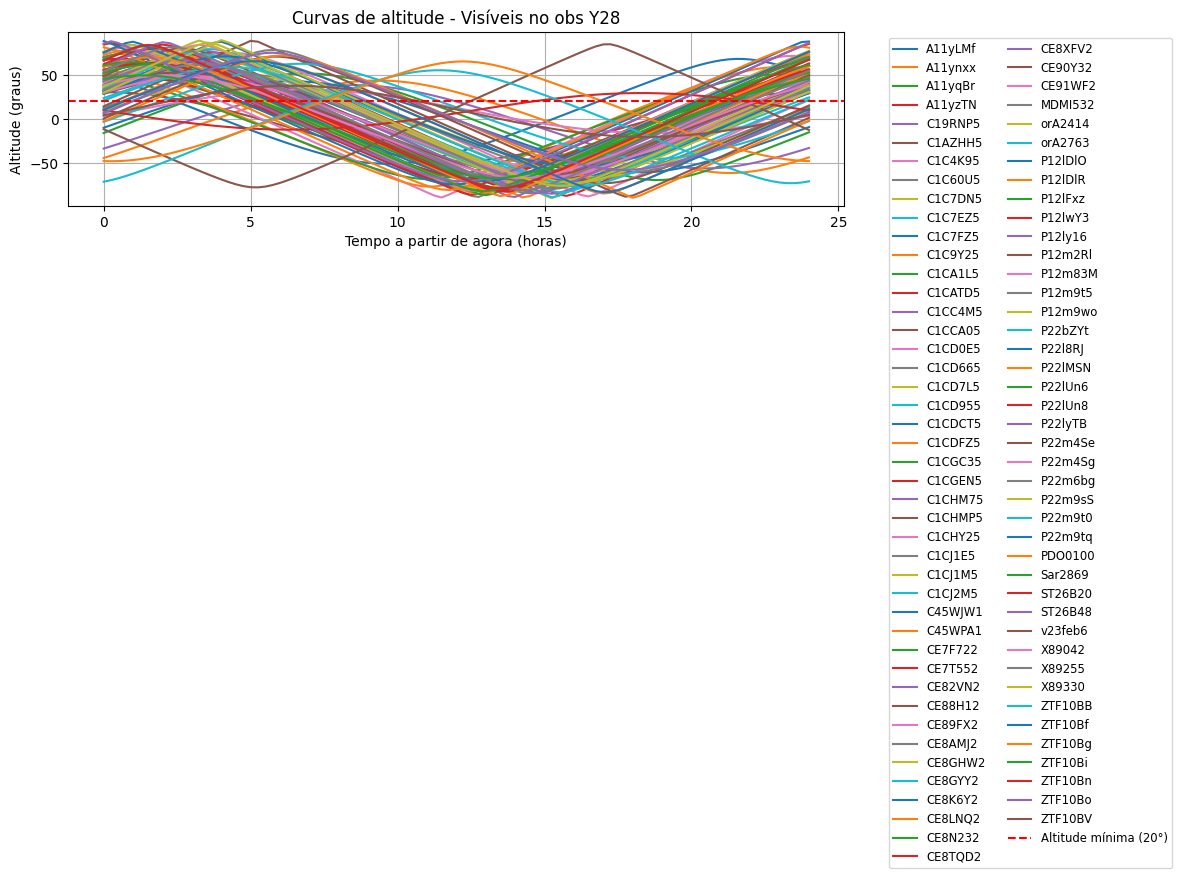

,Temp Desig,R.A.,Decl.,V,Visible_Minutes,Max_Alt
0,A11yLMf,06 41 08.7,-30 30 56,19.4,585,68.1
1,A11ynxx,18 22 46.9,+37 33 04,19.8,450,43.7
2,A11yqBr,15 54 15.6,+29 36 38,19.3,480,51.7
3,A11yzTN,12 46 00.7,+05 59 53,19.5,570,75.4
4,C19RNP5,17 33 51.9,+42 51 11,20.0,405,38.4
5,C1AZHH5,09 02 56.6,+50 54 35,24.1,360,30.5
6,C1C4K95,08 30 00.7,+09 42 53,22.6,570,71.6
7,C1C60U5,09 43 40.6,+07 30 41,22.6,570,73.9
8,C1C7DN5,10 50 24.9,+28 29 54,22.4,510,52.9
9,C1C7EZ5,10 33 12.7,+34 06 42,22.1,480,47.3


In [8]:

import importlib
importlib.reload(user) # Força o Python a ler o arquivo user.py atualizado!

# Roda a função
resultado = user.analyze_ephemeris_objects(code_obs, type_object, altitude_min, time_min, plot=True)

# Trava de segurança dupla
if resultado is not None and not resultado['visible_objects'].empty:
    display(resultado['visible_objects'][['Temp Desig', 'R.A.', 'Decl.', 'V', 'Visible_Minutes', 'Max_Alt']])
else:
    print("\nNenhum objeto visível encontrado ou falha na obtenção dos dados.")